<font color='tomato'><font color="#CC3D3D"><p>
# Baseline Code (v2.0)

- `SHAP`을 이용한 Feature selection 코드 추가
- `KMeansFeaturizer`을 이용한 Feature generation 코드 추가

##### Imports & Global Setting

In [4]:
import pandas as pd
import numpy as np
import os
import random
import pickle
import gzip
import gc
import re
import warnings; warnings.filterwarnings("ignore")
import seaborn as sns
import matplotlib.pylab as plt
from matplotlib import font_manager, rc
from tqdm import tqdm, tqdm_notebook
%matplotlib inline

from sklearn.impute import SimpleImputer 
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OrdinalEncoder
from sklearn.preprocessing import MinMaxScaler

from sklearn.cluster import KMeans


from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from xgboost import XGBClassifier
from sklearn.ensemble import BaggingClassifier, GradientBoostingClassifier

from sklearn.model_selection import cross_val_score
from sklearn.model_selection import KFold
from sklearn.metrics import accuracy_score
# import winsound as sd
# def beepsound():
#     fr = 2000    # range : 37 ~ 32767
#     du = 1000    # 1000 ms ==1second
#     sd.Beep(fr, du) # winsound.Beep(frequency, duration)
import shap # v2.0부터 추가

In [5]:
VERSION = 2.0
SHAP_THRESHOLD = 0.001  # v2.0부터 추가

### 데이터 설명
- **패널(Panel) 데이터**
  - userID: 패널 ID
  - BIRTH: 생일(연도)
  - GENDER: 1(남자) 2(여자)
  - REGION: 거주지역
  - TYPE: 패널 구분
  - SQ1 ~ DQ7: 패널 가입 시 설문조사 데이터로 각 필드에 대한 [상세설명](https://docs.google.com/spreadsheets/d/1pY6MYTSkyHrGLmMTU8tX_xlD8fPut6Ob/edit?usp=sharing&ouid=107121563618260277687&rtpof=true&sd=true) 참조
- **설문(Survey) 데이터**
  - surveyID: 설문 ID
  - TITLE: 설문 제목
  - IR: 난이도(응답가능성, 100이 최고)
  - LOI: 설문하는데 걸리는 시간 (분단위)
  - CATEGORIES: 설문 분류
  - CPI: 패널 응답 리워드 포인트(1P~)
- **응답(Response) 데이터**
  - STATUS: 응답여부 (Target)
  - (test 데이터의) ID: submission을 식별하기 위한 ID로 사용

SQ1 ~ DQ7 결측치도 많고 이게 응답률에 의미가 있을까?

- IR 숫자가 높을 수록 난이도 높
- LOI -시간
- CPI -리워드

* 설문응답률 설문데이터관련 피처가 중요할 것같음
* 테스트에서 ID는 인덱스의 의미
* 결측치 개많!
* 30%이하피쳐는 안썼음


# 01. Data Loading

In [6]:
train = pd.read_csv('../../data/train.csv', encoding='cp949')
test = pd.read_csv('../../data/test.csv', encoding='cp949')

In [7]:
original_features = train.columns
original_features

Index(['userID', 'surveyID', 'BIRTH', 'GENDER', 'REGION', 'TYPE', 'SQ1', 'SQ2',
       'SQ3', 'SQ4', 'SQ5', 'SQ6', 'SQ7', 'SQ8', 'A1', 'B1', 'B2', 'B3', 'B4',
       'B5', 'C1', 'C2', 'C3', 'F1', 'F2', 'H1', 'T1', 'X1', 'X2', 'X3', 'X4',
       'DQ1', 'DQ2', 'DQ3', 'DQ4', 'DQ5', 'DQ6', 'DQ7', 'TITLE', 'IR', 'LOI',
       'CATEGORIES', 'CPI', 'STATUS'],
      dtype='object')

# 02. Data Preprocessing

##### Clean data & derive features

In [8]:
# 결측값 비율이 30% 이하인 column만 사용(사용할 피처들만 출력)
features = []
for f in train.columns:
    if train[f].isnull().sum()/train.shape[0] <= 0.3:
        print(f, '\t', train[f].nunique(), '\t', train[f].isnull().sum()/train.shape[0])
        features.append(f)

userID 	 15155 	 0.0
surveyID 	 1293 	 0.0
BIRTH 	 76 	 0.0
GENDER 	 2 	 0.0
REGION 	 17 	 0.0
TYPE 	 3 	 0.0
SQ1 	 2 	 0.0009770785964481042
SQ2 	 82 	 0.0014293615190806859
SQ3 	 47 	 0.09023044306520002
SQ4 	 52 	 0.09058931973207153
SQ5 	 273 	 0.14450930989983407
SQ6 	 30 	 0.14490751551649972
SQ7 	 1234 	 0.1802556381736619
SQ8 	 1774 	 0.1831610643397038
A1 	 2768 	 0.2083279051189086
B1 	 131 	 0.21447796964296686
B2 	 120 	 0.2426792847047256
B3 	 110 	 0.24790757696798377
B4 	 715 	 0.2602888219750507
B5 	 669 	 0.26743317151109197
TITLE 	 1286 	 0.0
IR 	 42 	 0.0
LOI 	 26 	 0.0
CPI 	 43 	 0.0
STATUS 	 2 	 0.0


In [9]:
# 불필요한 ID들은 제외. SQ1 ~ SQ3는 GENDER, BIRTH, REGION과 중복이어서 제외!
# features.remove('userID')
# features.remove('surveyID')
features.remove('STATUS')
features.remove('SQ1')
features.remove('SQ2')
features.remove('SQ3')

In [10]:
# 거주 주택 형태: 1/2/3/4/5/6/97이 정상값
def handle_profile(x):
    if x in ['1', '2', '3', '4', '5', '6']:
        return int(x)
    elif x in ['1,', '2,', '3,', '4,', '5,', '6,']:
        return int(x[0])
    else:
        return 99

train.SQ4 = train.SQ4.apply(handle_profile)
test.SQ4 = test.SQ4.apply(handle_profile)

In [11]:
# 최종학력: 1/2/3/4 정상값
def handle_profile(x):
    if x in ['1', '2', '3', '4']:
        return int(x)
    elif x in ['1.0', '2.0', '3.0', '4.0']:
        return int(x[0])
    else:
        return 99

train.SQ5 = train.SQ5.apply(handle_profile)
test.SQ5 = test.SQ5.apply(handle_profile)

In [12]:
# 결혼여부: 1/2/97 정상값
def handle_profile(x):
    if x in ['1', '2']:
        return int(x)
    elif x in ['1,', '2,']:
        return int(x[0])
    else:
        return 99

train.SQ6 = train.SQ6.apply(handle_profile)
test.SQ6 = test.SQ6.apply(handle_profile)

In [13]:
# 자녀 정보: 1~16/99 정상값
value1 = pd.Series(range(1,17)).apply(lambda x: str(x)).tolist()
value2 = pd.Series(np.arange(1.0,17.0)).apply(lambda x: str(x)).tolist()
def handle_profile(x):
    if x in value1:
        return int(x)
    elif x in value2:
        return int(x[0])
    else:
        return 99

train.SQ7 = train.SQ7.apply(handle_profile)
test.SQ7 = test.SQ7.apply(handle_profile)

In [14]:
# 가족수: 1/2/3/4/5 정상값
def handle_profile(x):
    if x in ['1', '2', '3', '4', '5']:
        return int(x)
    else:
        return 99

train.SQ8 = train.SQ8.apply(handle_profile)
test.SQ8 = test.SQ8.apply(handle_profile)

In [15]:
# 최근 구입/렌트 가전제품: 1~22/99 정상값

## 최근 구매 사실에 대해서 설문조사를 진행했을 확률이 있을까?
values = pd.Series(range(1,23)).apply(lambda x: str(x)).tolist()
def handle_profile(x):    
    if x in values:
        return int(x)
    else:
        return 99

train.A1 = train.A1.apply(handle_profile)
test.A1 = test.A1.apply(handle_profile)

In [16]:
# 휴대폰 통신망 종류: 1~8/99 정상값
def handle_profile(x):    
    if x in ['1']:
        return 2
    elif x in ['2', '3']:
        return 3
    elif x in ['4', '5', '6', '7']:
        return 4
    elif x in ['8']:
        return 5
    else:
        return 99

train.B1 = train.B1.apply(handle_profile)
test.B1 = test.B1.apply(handle_profile)

In [17]:
# 가입한 이동통신사: 1~6/97 정상값 
def handle_profile(x):
    if x in ['1', '2', '3', '4', '5', '6']:
        return int(x)
    else:
        return 99

train.B2 = train.B2.apply(handle_profile)
test.B2 = test.B2.apply(handle_profile)

In [18]:
# 휴대폰 브랜드: 1~7/97/99 --1등
def handle_profile(x):    
    if x in ['1', '2', '3']:
        return int(x)
    elif x in ['1,', '2,', '3,']:
        return int(x[0])
    elif x in ['99', '99,']:
        return 99
    else:
        return 4  # 기타 제조사

train.B3 = train.B3.apply(handle_profile)
test.B3 = test.B3.apply(handle_profile)

In [19]:
# 보유 스마트 기기: 1~7/97/99  --1등
def handle_profile(x):    
    if x != x :
        return 0
    elif x in ['1', '2', '3', '4', '5', '6', '7' , '99', '97']:
        return int(x)
    else:
        return 98

train.B4 = train.B4.apply(handle_profile)
test.B4 = test.B4.apply(handle_profile)

In [20]:
# 케이블TV: 1~10/97/99  --1등
def handle_profile(x):    
    if x != x :
        return 0
    elif x in ['1', '2', '3', '4' ,'5', '6', '7', '8', '9', '10']:
        return int(x)
    elif x in ['1,', '2,', '3,', '4,' ,'5,', '6,', '7,', '8,', '9,', '10,']:
        return int(x[0])
    elif x in ['99', '99,']:
        return 99
    else:
        return 4  # 기타 제조사

train.B5 = train.B5.apply(handle_profile)
test.B5 = test.B5.apply(handle_profile)

In [21]:
def handle_profile(x):
    if x in ['1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11', '12', '13', '14']:
        return int(x)
    elif x in ['1,', '2,', '3,', '4,', '5,', '6,', '7,', '8,', '9,', '10,', '11,', '12,', '13,', '14,']:
        return int(x[0])
    else:
        return 99

train.C1 = train.C1.apply(handle_profile)
test.C1 = test.C1.apply(handle_profile)

In [22]:
def handle_profile(x):
    if x in ['1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11', '12', '13', '14']:
        return int(x)
    elif x in ['1,', '2,', '3,', '4,', '5,', '6,', '7,', '8,', '9,', '10,', '11,', '12,', '13,', '14,']:
        return int(x[0])
    else:
        return 99

train.C2 = train.C2.apply(handle_profile)
test.C2 = test.C2.apply(handle_profile)

In [23]:
def handle_profile(x):
    if x in ['1', '2', '3', '4', '5', '6', '7', '8', '9', '10']:
        return int(x)
    elif x in ['1,', '2,', '3,', '4,', '5,', '6,', '7,', '8,', '9,', '10,']:
        return int(x[0])
    else:
        return 99

train.C3 = train.C3.apply(handle_profile)
test.C3 = test.C3.apply(handle_profile)

### **< train_TITLE >** 피처

In [24]:
train_TITLE = train.copy()
test_TITLE = test.copy()

# 03. 피처추가 Feature Generation(FE_GN)

#### 01. 'RESRATE_round' : 응답률(RESRATE) 구간화

In [25]:
# 01. [RESRATE_round] : 응답률(RESRATE) 구간화

res_freq = train.query('STATUS == 1').groupby('userID')['userID'].agg([('FREQ',np.size)]).reset_index()
send_freq = train.groupby('userID')['userID'].agg([('SEND',np.size)]).reset_index()

train = train.merge(res_freq, how='left').merge(send_freq, how='left')
train['RESRATE'] = train['FREQ'] / train['SEND']
del train['FREQ'], train['SEND']
test = pd.merge(test, train.drop_duplicates(subset=['userID'])[['userID', 'RESRATE']], how='left')
test['RESRATE'] = test['RESRATE'].fillna(0)
### 결측값을 이렇게 처리하는게 최선일까?

#features.extend(['RESRATE'])    --> 피처 추가는 round된 버전으로!

# 구간화
train['RESRATE_round'] = round(train['RESRATE'],3) 
test['RESRATE_round'] = round(test['RESRATE'],3) 

features.extend(['RESRATE_round'])

#### 02. 'TYPE_RES_RATE' : 타입별 응답률

In [26]:
# 02. ['TYPE_RES_RATE'] : 타입별 응답률

response = train.groupby('TYPE')['STATUS'].agg([('TYPE_RES_RATE', lambda x: np.mean(x))]).reset_index()
train = train.merge(response, how='left', on='TYPE')
test = test.merge(response, how='left', on='TYPE')

features.extend(['TYPE_RES_RATE'])

#### 03. '리워드/시간'

In [27]:
# 03. ['리워드/시간'] 

train['리워드/시간'] = train['CPI'] / train['LOI']
test['리워드/시간'] = test['CPI'] / test['LOI']
features.extend(['리워드/시간'])

#### 04. '-(시간+난이도)_scaled' : -(시간+난이도) 스케일 진행

In [28]:
# 04. ['-(시간+난이도)_scaled'] : -(시간+난이도) 스케일 진행

# IR 피처에 대한 Min-Max Scaling
scaler = MinMaxScaler(feature_range=(1, 35))  # LOI의 범위에 맞춰서 설정
train['IR_scaled'] = scaler.fit_transform(train['IR'].values.reshape(-1, 1))
test['IR_scaled'] = scaler.fit_transform(test['IR'].values.reshape(-1, 1))

# 시간과 난이도의 합을 계산하여 새로운 피처 생성
train['-(시간+난이도)_scaled'] = -(train['IR_scaled'] + train['LOI'])
test['-(시간+난이도)_scaled'] = -(test['IR_scaled'] + test['LOI'] )
features.extend(['-(시간+난이도)_scaled'])

#### 05. '대상지역', '대상자유형_일반인', '대상자유형_소비자'

In [29]:
# 05. ['대상지역', '대상자유형_일반인', '대상자유형_소비자']

'''TRAIN'''
대상지역 = np.where(train_TITLE['TITLE'].str.contains('해외'), '해외', '기타')
대상자유형_일반인 = np.where(train_TITLE['TITLE'].str.contains('일반인'), '일반인', '기타')
대상자유형_소비자 = np.where(train_TITLE['TITLE'].str.contains('소비자'), '소비자', '기타')

### 생성된 배열을 시리즈로 변환
대상지역 = pd.Series(대상지역, name='대상지역')
대상자유형_일반인 = pd.Series(대상자유형_일반인, name='대상자유형_일반인')
대상자유형_소비자 = pd.Series(대상자유형_소비자, name='대상자유형_소비자')

### 데이터프레임에 병합
train = pd.concat([train, 대상지역, 대상자유형_일반인, 대상자유형_소비자], axis=1)

In [30]:
'''TEST'''
대상지역 = np.where(test_TITLE['TITLE'].str.contains('해외'), '해외', '기타')
대상자유형_일반인 = np.where(test_TITLE['TITLE'].str.contains('일반인'), '일반인', '기타')
대상자유형_소비자 = np.where(test_TITLE['TITLE'].str.contains('소비자'), '소비자', '기타')

### 생성된 배열을 시리즈로 변환
대상지역 = pd.Series(대상지역, name='대상지역')
대상자유형_일반인 = pd.Series(대상자유형_일반인, name='대상자유형_일반인')
대상자유형_소비자 = pd.Series(대상자유형_소비자, name='대상자유형_소비자')

### 데이터프레임에 병합
test = pd.concat([test, 대상지역, 대상자유형_일반인, 대상자유형_소비자], axis=1)

features.extend(['대상지역', '대상자유형_일반인', '대상자유형_소비자'])

#### 06. 'Points_earned_bins' 

In [31]:
# 06. '[Points_earned_bins'] : 패널 ID 별 획득 누적 포인트

#Points_earned = pd.DataFrame(train.query('STATUS==1').groupby('userID')['CPI'].agg([('Points_earned',np.sum)])).reset_index()
Points_earned = pd.DataFrame(train.query('STATUS==1').groupby('userID')['CPI'].agg([('Points_earned',np.sum)])).reset_index()

# 패널 ID 별 획득 평균 포인트
Points_earned_mean = pd.DataFrame(train.query('STATUS==1').groupby('userID')['CPI'].agg([('Points_earned_mean',np.mean)])).reset_index()

train = train.merge(Points_earned, how='left')
train = train.merge(Points_earned_mean, how='left')
train['Points_earned'].fillna(0, inplace = True)
train['Points_earned_mean'].fillna(0, inplace = True)

test = test.merge(Points_earned, how='left')
test = test.merge(Points_earned_mean, how='left')
test['Points_earned'].fillna(0, inplace = True)
test['Points_earned_mean'].fillna(0, inplace = True)

#features.extend(['Points_earned_mean'])

'''구간화'''
# 0부터 1170까지는 20씩, 1200에서 2000까지는 하나의 구간으로 설정
bin_edges = list(range(0, 1200, 20)) + [2000]

# 구간에 대한 라벨 설정
bin_labels = [f'{i}-{i+19}' for i in range(0, 1180, 20)] + ['1200-2000']

# 'Points_earned_mean' 열을 구간화하여 새로운 열로 추가
train['Points_earned_bins'] = pd.cut(train['Points_earned_mean'], bins=bin_edges, labels=bin_labels, include_lowest=True)
test['Points_earned_bins'] = pd.cut(test['Points_earned_mean'], bins=bin_edges, labels=bin_labels, include_lowest=True)

features.append('Points_earned_bins')

#### 07. 'RES_RATE_survey_sum_log'

In [32]:
# 07. ['RES_RATE_survey_sum_log'] : 응답률 * 서베이 횟수

survey_count = train.groupby('userID')['userID'].count()#.reset_index()
survey_count.name = 'user'
survey_count.reset_index()
RES_RATE = train.STATUS.groupby(train.userID).sum() / train.STATUS.groupby(train.userID).count()

RES_RATE_survey_sum = RES_RATE*survey_count
RES_RATE_survey_sum.name = 'RES_RATE_survey_sum'

train = train.merge(RES_RATE_survey_sum,on='userID', how = 'left')
test = test.merge(RES_RATE_survey_sum,on='userID', how = 'left')
# features.extend(['RES_RATE_survey_sum'])'


### RES_RATE_survey_sum 로그 변환
train['RES_RATE_survey_sum_log'] = np.log(train['RES_RATE_survey_sum'] + 1)  # +1을 더해줘서 0이하의 값이 없도록 보정
test['RES_RATE_survey_sum_log'] = np.log(test['RES_RATE_survey_sum'] + 1)  # +1을 더해줘서 0이하의 값이 없도록 보정
features.extend(['RES_RATE_survey_sum_log'])

#### 08. 'RESRATE_S_round'

In [33]:
# 설문별 응답률 (RESRATE_S) 생성
res_freq = train.query('STATUS == 1').groupby('surveyID')['surveyID'].agg([('FREQ',np.size)]).reset_index()
send_freq = train.groupby('surveyID')['surveyID'].agg([('SEND',np.size)]).reset_index()

train = train.merge(res_freq, how='left').merge(send_freq, how='left')
train['RESRATE_S'] = train['FREQ'] / train['SEND']
del train['FREQ'], train['SEND']

test = pd.merge(test, train.drop_duplicates(subset=['surveyID'])[['surveyID', 'RESRATE_S']], how='left')
test['RESRATE_S'] = test['RESRATE_S'].fillna(0)
### 결측값을 이렇게 처리하는게 최선일까?

features.extend(['RESRATE_S'])


# RESRATE_S 구간화
train['RESRATE_S_round'] = round(train['RESRATE_S'],3) 
test['RESRATE_S_round'] = round(test['RESRATE_S'],3) 

features.extend(['RESRATE_S_round'])

In [34]:
# Survey 제목에서 유용한 정보 추출 
# train.TITLE.value_counts()
### 약 
word_counts = {}
def count_word(x): # 응답한 서베이 제목에서 한글 단어만 분리하고 빈도 계산
    if x['STATUS'] == 1:
        for w in re.sub(r'[^ ㄱ-ㅣ가-힣]', '', x['TITLE']).split():
            word_counts[w] = word_counts.get(w, 0) + 1
def score_word(x): # 빈도의 합으로 제목을 Encoding
    score = 0
    for w in re.sub(r'[^ ㄱ-ㅣ가-힣]', '', x['TITLE']).split():
        score += word_counts.get(w, 0)
    return score    
            
train.apply(count_word, axis=1)
train.TITLE = train.apply(score_word, axis=1)
test.TITLE = test.apply(score_word, axis=1)

# 04. 데이터 필터링


In [35]:
#데이터 필터링
X_train = train[features]
X_test = test[features]
y_train = train['STATUS']

# submission을 만들 때 사용하기 위해 ID 저정
ID_test = test.ID

'''# 메모리 낭비를 막기위해 불필요한 데이터 삭제
del train, test 
gc.collect()'''

'# 메모리 낭비를 막기위해 불필요한 데이터 삭제\ndel train, test \ngc.collect()'

# 05. Feature Engineering

In [36]:
# 범주형 변수와 수치형 변수를 분리
def separate_features(df):
    num_features = df.select_dtypes(include=['number']).columns.tolist()
    cat_features = df.select_dtypes(exclude=['number']).columns.tolist()
    return num_features, cat_features

num_features, cat_features = separate_features(X_train)

In [37]:
print(len(num_features))
print(len(cat_features))

25
7


##### 1) Impute missing values

In [38]:
# 범주형이냐 수치형이냐에 따라 다르게 처리
if len(num_features) > 0:
    imp = SimpleImputer(strategy='mean')
    X_train[num_features] = imp.fit_transform(X_train[num_features])
    X_test[num_features] = imp.transform(X_test[num_features])
if len(cat_features) > 0:  
    imp = SimpleImputer(strategy="most_frequent")
    X_train[cat_features] = imp.fit_transform(X_train[cat_features])
    X_test[cat_features] = imp.transform(X_test[cat_features])


X_train['GENDER'] = X_train['GENDER'].astype(int)
X_train['REGION'] = X_train['REGION'].astype(int)
X_test['GENDER'] = X_test['GENDER'].astype(int)
X_test['REGION'] = X_test['REGION'].astype(int)

##### 2) Transform features (Feature Scaling)

In [39]:
scaler = StandardScaler()
X_train[num_features] = scaler.fit_transform(X_train[num_features])
X_test[num_features] = scaler.transform(X_test[num_features])

##### 3) Encode categorical features

In [40]:
Oe = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1, dtype=int)
X_train[cat_features] = Oe.fit_transform(X_train[cat_features])
X_test[cat_features] = Oe.transform(X_test[cat_features])

In [41]:
# SHAP 이전 컬럼 개수
print(X_train.shape)
print(X_test.shape)
print(len(features))
print(features)

(813650, 32)
(541867, 32)
32
['userID', 'surveyID', 'BIRTH', 'GENDER', 'REGION', 'TYPE', 'SQ4', 'SQ5', 'SQ6', 'SQ7', 'SQ8', 'A1', 'B1', 'B2', 'B3', 'B4', 'B5', 'TITLE', 'IR', 'LOI', 'CPI', 'RESRATE_round', 'TYPE_RES_RATE', '리워드/시간', '-(시간+난이도)_scaled', '대상지역', '대상자유형_일반인', '대상자유형_소비자', 'Points_earned_bins', 'RES_RATE_survey_sum_log', 'RESRATE_S', 'RESRATE_S_round']


<font color="#CC3D3D"><p>
### **Feature selection using SHAP**

[LightGBM] [Info] Number of positive: 316565, number of negative: 497085
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.032482 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1981
[LightGBM] [Info] Number of data points in the train set: 813650, number of used features: 32
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.389068 -> initscore=-0.451232
[LightGBM] [Info] Start training from score -0.451232


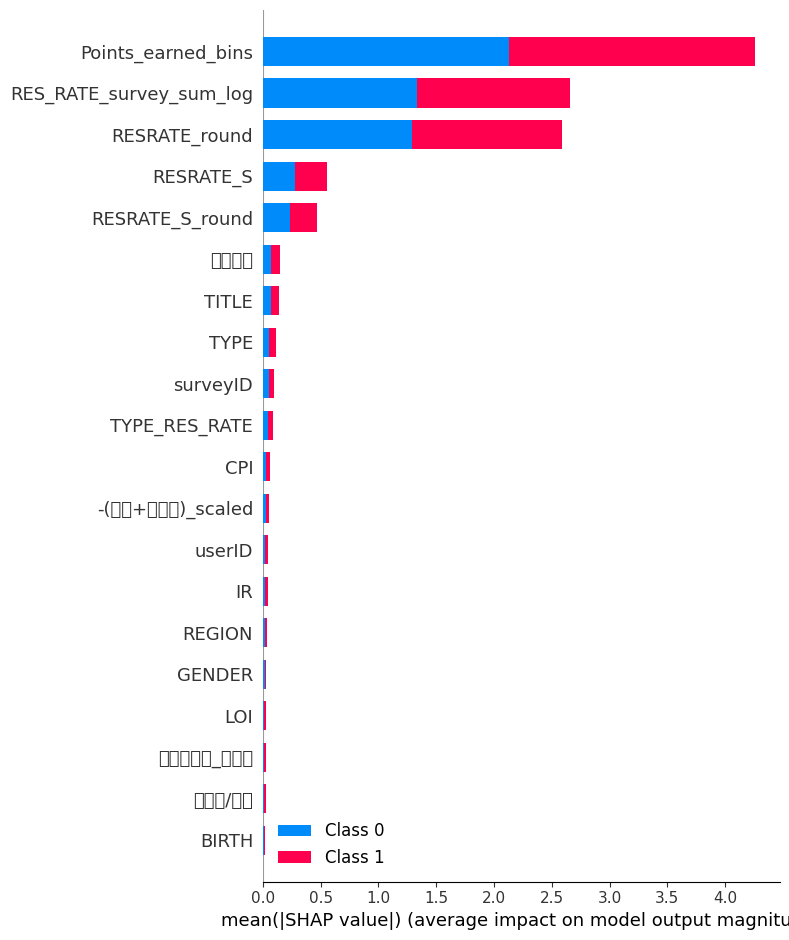

,column_name,shap_importance
28,Points_earned_bins,2.130433
29,RES_RATE_survey_sum_log,1.329508
21,RESRATE_round,1.292233
30,RESRATE_S,0.277744
31,RESRATE_S_round,0.233516
25,대상지역,0.074215
17,TITLE,0.067787
5,TYPE,0.055629
1,surveyID,0.049975
22,TYPE_RES_RATE,0.042586


In [42]:
# SHAP values 
### 약 2분 소요

# DF, based on which importance is checked
X_importance = X_test

# # Explain model predictions using shap library:
#LGBM쓰면 빨리 돌려지니까 이걸로 피처 추가하는 거겠지
model = LGBMClassifier(random_state=0).fit(X_train, y_train)
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_importance)

# Plot summary_plot as barplot:
shap.summary_plot(shap_values, X_importance, plot_type='bar') #shap_values피처 중요도 

shap_sum = np.abs(shap_values).mean(axis=1)[1,:]
importance_df = pd.DataFrame([X_importance.columns.tolist(), shap_sum.tolist()]).T
importance_df.columns = ['column_name', 'shap_importance']
importance_df = importance_df.sort_values('shap_importance', ascending=False)
importance_df

In [43]:
# 지정된(SHAP_THRESHOLD) Shap feature 중요도 이상인 것만 선택
### 원래 143개였는데 117개됨
features_selected = importance_df.query('shap_importance > @SHAP_THRESHOLD').column_name.tolist()
X_train = X_train[features_selected]
X_test = X_test[features_selected]

print(X_train.shape)

(813650, 24)


# **06. Model building**

#### LGBM

In [44]:
model_lgbm = LGBMClassifier(n_estimators=4000, learning_rate=0.05, objective='binary', metric='binary_error', random_state=44)
lgbm_pred = np.zeros((X_test.shape[0]))
accuracy_list = []
list_lgbm = []

threshold = 0.5 
spl = 5

kf = KFold(n_splits=spl, shuffle=True, random_state=42)

for tr_idx, val_idx in tqdm(kf.split(X_train, y_train)):
    tr_x, tr_y = X_train.iloc[tr_idx], y_train.iloc[tr_idx]
    val_x, val_y = X_train.iloc[val_idx], y_train.iloc[val_idx]
    
    model_lgbm.fit(tr_x, tr_y, eval_metric = 'accuracy')
    pred = model_lgbm.predict(val_x)

    accuracy = accuracy_score(val_y, pred)
    accuracy_list.append(accuracy)
    print(accuracy)
    
    sub_pred = np.array(model_lgbm.predict_proba(X_test)[:, 1])  # X_test에 대한 예측값 구하기
    lgbm_pred += sub_pred

# 최종 예측값 구하기 (5-fold의 평균값 사용)
final_predictions_lgbm = (lgbm_pred / spl >= 0.495).astype(int)
print(final_predictions_lgbm)
print(f'{model_lgbm.__class__.__name__}의 fold 평균 Accuracy는 {np.mean(accuracy_list)}')

0it [00:00, ?it/s]

[LightGBM] [Info] Number of positive: 253249, number of negative: 397671
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.013105 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1909
[LightGBM] [Info] Number of data points in the train set: 650920, number of used features: 24
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.389063 -> initscore=-0.451252
[LightGBM] [Info] Start training from score -0.451252
0.8699932403367542


1it [00:32, 32.91s/it]

[LightGBM] [Info] Number of positive: 253255, number of negative: 397665
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.011412 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1903
[LightGBM] [Info] Number of data points in the train set: 650920, number of used features: 24
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.389072 -> initscore=-0.451213
[LightGBM] [Info] Start training from score -0.451213
0.8697044183617034


2it [01:06, 33.24s/it]

...

[LightGBM] [Info] Number of positive: 253073, number of negative: 397847
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.013866 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1909
[LightGBM] [Info] Number of data points in the train set: 650920, number of used features: 24
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.388793 -> initscore=-0.452390
[LightGBM] [Info] Start training from score -0.452390
0.8706937872549622


4it [02:12, 33.22s/it]

[LightGBM] [Info] Number of positive: 253186, number of negative: 397734
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.016848 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1906
[LightGBM] [Info] Number of data points in the train set: 650920, number of used features: 24
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.388966 -> initscore=-0.451659
[LightGBM] [Info] Start training from score -0.451659
0.869606095987218


5it [02:47, 33.52s/it]

[1 1 1 ... 0 0 1]
LGBMClassifier의 fold 평균 Accuracy는 0.8701087691267745


#### XGB

In [ ]:
import optuna
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import KFold

# X_train, y_train이 이미 정의되어 있다고 가정한다.

def objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 500, 5000),
        'max_depth': trial.suggest_int('max_depth', 3, 15),
        'learning_rate': trial.suggest_loguniform('learning_rate', 0.005, 0.5),
        'subsample': trial.suggest_discrete_uniform('subsample', 0.6, 0.95, 0.05),
        'colsample_bytree': trial.suggest_discrete_uniform('colsample_bytree', 0.6, 0.95, 0.05),
        'gamma': trial.suggest_loguniform('gamma', 1e-8, 1.0),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 20),
        'random_state': 0,
        'eval_metric': 'error',
        'objective': 'binary:logistic',
        'verbosity': 0
    }

    model = XGBClassifier(**params)
    spl = 5
    kf = KFold(n_splits=spl, shuffle=True, random_state=42)
    accuracy_list = []

    for tr_idx, val_idx in kf.split(X_train, y_train):
        tr_x, tr_y = X_train.iloc[tr_idx], y_train.iloc[tr_idx]
        val_x, val_y = X_train.iloc[val_idx], y_train.iloc[val_idx]

        # Train/validation split for early stopping
        train_x, valid_x, train_y, valid_y = train_test_split(
            tr_x, tr_y, test_size=0.2, random_state=42
        )

        model.fit(
            train_x, train_y,
            eval_set=[(valid_x, valid_y)],
            early_stopping_rounds=100,  # Set an appropriate early stopping round
            verbose=False
        )

        pred = model.predict(val_x)
        accuracy = accuracy_score(val_y, pred)
        accuracy_list.append(accuracy)

    return np.mean(accuracy_list)

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=300)

best_params = study.best_params
print(f"Best trial: {best_params}")


[I 2023-12-20 06:32:08,824] A new study created in memory with name: no-name-6ebe9aaf-2e32-43da-8707-4d1b4afedc94
[I 2023-12-20 06:34:31,109] Trial 0 finished with value: 0.8681288023105758 and parameters: {'n_estimators': 1618, 'max_depth': 15, 'learning_rate': 0.005438331510024666, 'subsample': 0.95, 'colsample_bytree': 0.9, 'gamma': 1.1009826314594154e-07, 'min_child_weight': 13}. Best is trial 0 with value: 0.8681288023105758.
[I 2023-12-20 06:35:03,169] Trial 1 finished with value: 0.868447120997972 and parameters: {'n_estimators': 3181, 'max_depth': 13, 'learning_rate': 0.09326794539893259, 'subsample': 0.95, 'colsample_bytree': 0.65, 'gamma': 0.31139616279586513, 'min_child_weight': 20}. Best is trial 1 with value: 0.868447120997972.
[I 2023-12-20 06:37:04,854] Trial 2 finished with value: 0.8688146008726111 and parameters: {'n_estimators': 3906, 'max_depth': 15, 'learning_rate': 0.008777140375086853, 'subsample': 0.65, 'colsample_bytree': 0.8, 'gamma': 1.269824260750846e-07, 'm

In [ ]:
from xgboost import XGBClassifier
import numpy as np
from sklearn.model_selection import KFold
from sklearn.metrics import accuracy_score
from tqdm import tqdm

# 최적의 하이퍼파라미터 설정
best_params = {
    'n_estimators': 1146,
    'max_depth': 9,
    'learning_rate': 0.02534583366384355,
    'subsample': 0.85,
    'colsample_bytree': 0.9,
    'gamma': 0.03967425666846014,
    'min_child_weight': 4
}

model_xgb = XGBClassifier(**best_params, eval_metrics='error', objective='binary:logistic', random_state=0, verbose=200)
xgb_pred = np.zeros((X_test.shape[0]))
accuracy_list = []
threshold = 0.5
spl = 5

kf = KFold(n_splits=spl, shuffle=True, random_state=42)

for tr_idx, val_idx in tqdm(kf.split(X_train, y_train)):
    tr_x, tr_y = X_train.iloc[tr_idx], y_train.iloc[tr_idx]
    val_x, val_y = X_train.iloc[val_idx], y_train.iloc[val_idx]
    
    model_xgb.fit(tr_x, tr_y)
    pred = model_xgb.predict(val_x)

    accuracy = accuracy_score(val_y, pred)
    accuracy_list.append(accuracy)
    print(accuracy)
    
    sub_pred = np.array(model_xgb.predict_proba(X_test)[:, 1])  # X_test에 대한 예측값 구하기
    xgb_pred += sub_pred

# 최종 예측값 구하기 (5-fold의 평균값 사용)
final_predictions_xgb = (xgb_pred / spl >= 0.495).astype(int)
print(final_predictions_xgb)
print(f'{model_xgb.__class__.__name__}의 fold 평균 Accuracy는 {np.mean(accuracy_list)}')

#### CAT

In [ ]:
model_cb = CatBoostClassifier(eval_metric= 'Accuracy',loss_function = "CrossEntropy", random_state=0, verbose = 200)
lgbm_pred = np.zeros((X_test.shape[0]))
accuracy_list = []
list_lgbm = []

threshold = 0.5 
spl = 5

kf = KFold(n_splits=spl, shuffle=True, random_state=42)

for tr_idx, val_idx in tqdm(kf.split(X_train, y_train)):
    tr_x, tr_y = X_train.iloc[tr_idx], y_train.iloc[tr_idx]
    val_x, val_y = X_train.iloc[val_idx], y_train.iloc[val_idx]
    
    model_cb.fit(tr_x, tr_y)
    pred = model_cb.predict(val_x)

    accuracy = accuracy_score(val_y, pred)
    accuracy_list.append(accuracy)
    print(accuracy)
    
    sub_pred = np.array(model_cb.predict_proba(X_test)[:, 1])  # X_test에 대한 예측값 구하기
    lgbm_pred += sub_pred

# 최종 예측값 구하기 (5-fold의 평균값 사용)
final_predictions_cb = (lgbm_pred / spl >= 0.495).astype(int)
print(final_predictions_cb)
print(f'{model_cb.__class__.__name__}의 fold 평균 Accuracy는 {np.mean(accuracy_list)}')

In [ ]:
# 위 모델의 예측값을 더하고 모델 개수만큼 나누어 평균 계산
avg_predictions = (final_predictions_lgbm + final_predictions_xgb + final_predictions_cb) / 3

# 평균값을 기준으로 0 또는 1로 예측
threshold = 0.5  # 임계값 설정
final_predictions = np.where(avg_predictions >= threshold, 1, 0)

print(final_predictions)

In [ ]:
len(final_predictions)

In [ ]:
t = pd.Timestamp.now()
fname = f"oof_hardvoting_1220_kmeans{t.month:02}{t.day:02}{t.hour:02}{t.minute:02}.csv"
pd.DataFrame({'ID': ID_test, 'STATUS': final_predictions}).to_csv(fname, index=False)
print(f"'{fname}' is ready to submit.")